# Ungraded Lab: DataFrame Operations Lab

## Overview 
In this hands-on lab, you'll work with EngageMetrics employee and education data using pandas DataFrame operations. You'll learn to merge, filter, and analyze data to gain practical insights about employee educational backgrounds and work metrics. These skills are essential for data scientists working with multiple data sources.

Need help along the way? Don't hesitate to revisit this lesson’s screencast - this is a common practice in professional development and helps reinforce your learning.

## Learning Outcomes 
By the end of this lab, you will be able to:
- Merge multiple datasets using pandas DataFrame operations
- Filter and group data to extract meaningful insights
- Handle common data cleaning challenges in real datasets
- Create analytical summaries using DataFrame aggregations

## Dataset Information 
We'll work with two EngageMetrics datasets:
- <b>education_data.xlsx:</b> Contains employee educational backgrounds including graduation years and fields of study
- <b>employee_insights.csv:</b> Contains employee performance metrics, satisfaction scores, and work-related information

## Activities

### Activity 1: Data Loading and Initial Exploration

<b>Step 1:</b> Import required libraries and load datasets:

In [1]:
import pandas as pd

# Load the datasets
education_df = pd.read_excel('education_data.xlsx')
employee_df = pd.read_csv('employee_insights.csv')

<b>Step 2:</b> Examine the data:

In [2]:
# Display first few rows of each dataset
print("Education Data:")
print(education_df.head())

print("\nEmployee Data:")
print(employee_df.head())

Education Data:
      ID  graduation_year   educational_background
0  E0001             2011               Psychology
1  E0002             1995             Architecture
2  E0003             2007  Business Administration
3  E0004             2000  Business Administration
4  E0005             1991                 Medicine

Employee Data:
  employee_id   age  salary promotion_eligible last_training_date department  \
0       E0001  54.0     NaN                NaN         15/08/2023         HR   
1       E0002   NaN  $64761                  N         15/08/2023        NaN   
2       E0003  54.0     NaN                  N         15/08/2023  Marketing   
3       E0004   NaN     NaN                 No                NaN        NaN   
4       E0005  29.0  $61486                  Y         15/08/2023        NaN   

  work_experience  projects_completed  hours_worked_weekly    work_mode  \
0             NaN                14.0                  NaN  remote work   
1         1 years              

<b>Tip:</b> Always check your data types and missing values after loading datasets.

### Activity 2: Data Cleaning and Preparation
<b>Step 1:</b> Clean the work_mode column:

In [3]:
# Standardize work mode values
# Step: Data Standardization / Estandarización de Datos.
# Action: Removing leading/trailing spaces and converting to lowercase to ensure categorical consistency.
# Acción: Eliminación de espacios en los extremos y conversión a minúsculas para asegurar la consistencia categórica.
employee_df['work_mode'] = employee_df['work_mode'].str.strip().str.lower()
#Verify unique categories after standardization / Verificar categorias unicas despues de la estandarización
print(employee_df['work_mode'].unique())
# How many employees are in each cateogy / Cuantos empleados hay por categoria
print(employee_df['work_mode'].value_counts())


<StringArray>
['remote work', 'hybrid', 'remote', nan, 'on-site']
Length: 5, dtype: str
work_mode
hybrid         33
remote work    19
on-site        17
remote         15
Name: count, dtype: int64


In [4]:
# I'll change the remote work to remote / Voy a cambiar el remote work a remote
employee_df['work_mode'] = employee_df['work_mode'].str.replace('remote work','remote')
#Verify unique categories after standardization / Verificar categorias unicas despues de la estandarización
print(employee_df['work_mode'].unique())
# How many employees are in each cateogy / Cuantos empleados hay por categoria
print(employee_df['work_mode'].value_counts())  

<StringArray>
['remote', 'hybrid', nan, 'on-site']
Length: 4, dtype: str
work_mode
remote     34
hybrid     33
on-site    17
Name: count, dtype: int64


<b>Step 2:</b> Handle missing values:

In [5]:
# Your code here to handle missing values
# Check missing values per column / Verificar valores nulos por columna
print('\nMissing values per column:\n')
print(employee_df.isnull().sum())
# Contrast with the percentage / Contrastar con el porcentaje
print('\nPercentage of null values:\n')
print(employee_df.isnull().mean()*100)


Missing values per column:

employee_id             0
age                    56
salary                 37
promotion_eligible     16
last_training_date     29
department             15
work_experience        29
projects_completed     52
hours_worked_weekly    33
work_mode              16
last_promotion_date    26
satisfaction_score     39
overtime_hours         30
dtype: int64

Percentage of null values:

employee_id             0.0
age                    56.0
salary                 37.0
promotion_eligible     16.0
last_training_date     29.0
department             15.0
work_experience        29.0
projects_completed     52.0
hours_worked_weekly    33.0
work_mode              16.0
last_promotion_date    26.0
satisfaction_score     39.0
overtime_hours         30.0
dtype: float64


<Axes: >

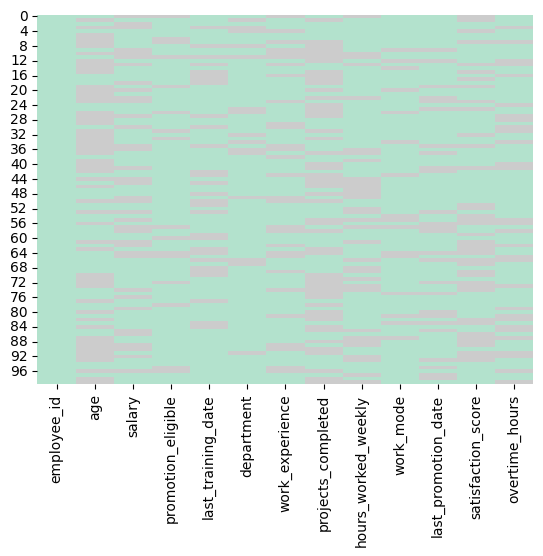

In [6]:
# I use a heatmap to visualize better the null values / Usaré el mapa de calor para visualizar mejor los nulos
import seaborn as sns
sns.heatmap(employee_df.isnull(), cbar=False, cmap='Pastel2')

## Note / Nota 
### As the "age" and "projects_completed" are not needed for the final analysis I'll drop them and for the other columns I'll use the mode and media.
### Como la columna "age" y "projects_completed" no son necesarios para el analisis final, los voy a borrar y para las demás variables usaré la moda y mediana.

In [7]:
# Columns age and projects_completed are dropped / Columnas "age" y "projects_completed" son eliminadas
employee_df.drop(columns=['age', 'projects_completed'], inplace=True)

In [8]:
# Fill missing numeric values with median
numeric_columns = employee_df.select_dtypes(include=['number']).columns
employee_df[numeric_columns] = employee_df[numeric_columns].fillna(employee_df[numeric_columns].median())

In [9]:
# Fill missing categorical values with mode
# Seleccionamos explícitamente 'object' y 'string' para evitar el Warning
categorical_columns = employee_df.select_dtypes(include=['object', 'string']).columns
employee_df[categorical_columns] = employee_df[categorical_columns].fillna(employee_df[categorical_columns].mode().iloc[0])


Missing values per column:

employee_id            0
salary                 0
promotion_eligible     0
last_training_date     0
department             0
work_experience        0
hours_worked_weekly    0
work_mode              0
last_promotion_date    0
satisfaction_score     0
overtime_hours         0
dtype: int64

Percentage of null values:

employee_id            0.0
salary                 0.0
promotion_eligible     0.0
last_training_date     0.0
department             0.0
work_experience        0.0
hours_worked_weekly    0.0
work_mode              0.0
last_promotion_date    0.0
satisfaction_score     0.0
overtime_hours         0.0
dtype: float64


<Axes: >

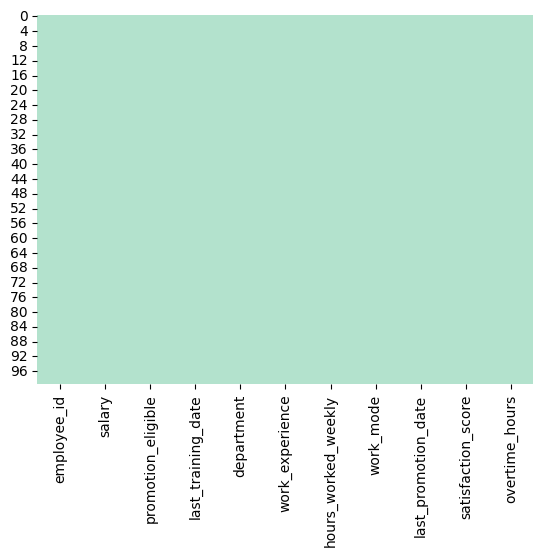

In [10]:
# Your code here to handle missing values
# Check missing values per column / Verificar valores nulos por columna
print('\nMissing values per column:\n')
print(employee_df.isnull().sum())
# Contrast with the percentage / Contrastar con el porcentaje
print('\nPercentage of null values:\n')
print(employee_df.isnull().mean()*100)

# I use a heatmap to visualize better the null values / Usaré el mapa de calor para visualizar mejor los nulos
import seaborn as sns
sns.heatmap(employee_df.isnull(), cbar=False, cmap='Pastel2')

### Activity 3: Merging Datasets
<b>Step 1:</b> Merge education and employee datasets:

In [11]:
# Merge datasets on employee_id
merged_df = pd.merge(
    employee_df,
    education_df,
    left_on='employee_id',
    right_on='ID',
    how='inner'
)
merged_df.head() #employee_id and id are both in the df so I'll delete ID
merged_df.drop(columns=['ID'], inplace=True)
merged_df.head()

,employee_id,salary,promotion_eligible,last_training_date,department,work_experience,hours_worked_weekly,work_mode,last_promotion_date,satisfaction_score,overtime_hours,graduation_year,educational_background
0,E0001,$104328,Y,15/08/2023,HR,16 years,43.3,remote,2022-05-10,6.0,8.40,2011,Psychology
1,E0002,$64761,N,15/08/2023,Finance,1 years,53.3,hybrid,05-10-2022,6.0,8.10,1995,Architecture
2,E0003,$104328,N,15/08/2023,Marketing,8,32.6,hybrid,10/05/2022,10.0,5.20,2007,Business Administration
3,E0004,$104328,No,15/08/2023,Finance,16,37.8,remote,05-10-2022,5.0,6.15,2000,Business Administration
4,E0005,$61486,Y,15/08/2023,Finance,16 years,53.3,hybrid,2022-05-10,6.0,0.30,1991,Medicine


### Activity 4: Analysis and Insights
<b>Step 1:</b> Calculate average satisfaction scores by educational background:

In [12]:
# Step 1: Calculate average satisfaction scores by educational background:
# Group by educational background and calculate the satisfaction avg / Agrupamos por nivel educativo y calculamos el promedio de satisfacción
avg_satisfaction = merged_df.groupby('educational_background')['satisfaction_score'].mean()

# We sort from highest to lowest to see who is satisfied / Ordenamos de mayor a menor para ver quiénes están más satisfecho
avg_satisfaction = avg_satisfaction.sort_values(ascending=False)

print("Average Satisfaction by Educational Background:")
display(avg_satisfaction)

Average Satisfaction by Educational Background:


educational_background
Chemistry                  7.333333
Philosophy                 6.600000
Mathematics                6.571429
Architecture               6.500000
Biology                    6.500000
Computer Science           6.500000
Medicine                   6.222222
Physics                    6.142857
Linguistics                5.857143
Business Administration    5.666667
Law                        5.333333
Political Science          5.333333
Engineering                5.142857
Psychology                 4.888889
Economics                  4.857143
Statistics                 3.375000
Name: satisfaction_score, dtype: float64

<b>Step 2:</b> Visualize the average satisfaction scores:

In [13]:
# Step 2: Visualize the average satisfaction scores
import matplotlib.pyplot as plt
import seaborn as sns


## This visualization was created with the help of AI because I wanted something eye-catching / Esta visualización se creó con la ayuda de IA porque quería algo llamativo

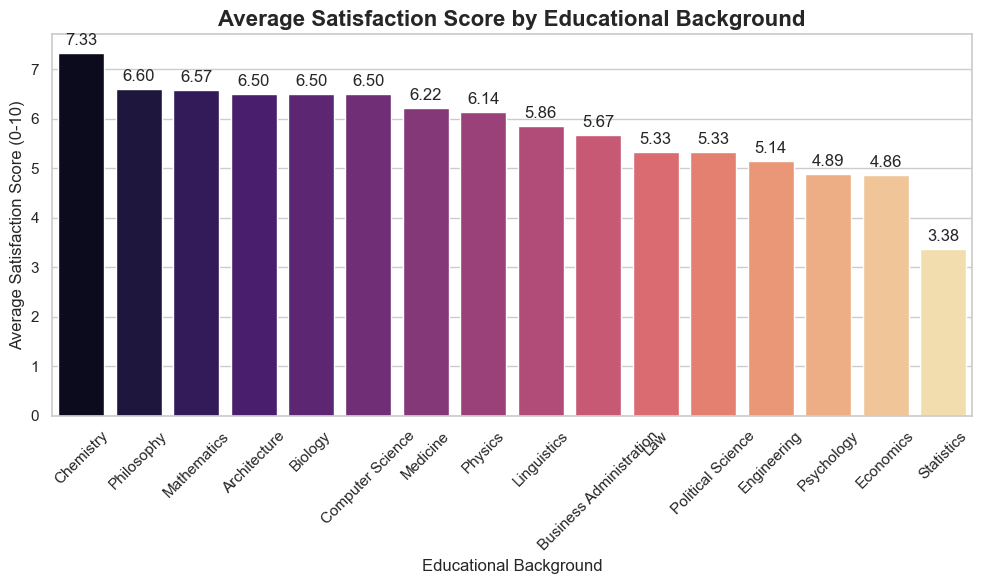

In [14]:
# 1. Set up the visual style (clean and professional)
# 1. Configurar el estilo visual (limpio y profesional)
sns.set_theme(style="whitegrid")

# 2. Create the canvas (Figure)
# 2. Crear el lienzo (Figura)
plt.figure(figsize=(10, 6))

# 3. Create the bar graph
# 3. Crear el gráfico de barras
ax = sns.barplot(
    x=avg_satisfaction.index, 
    y=avg_satisfaction.values, 
    palette='magma',
    hue=avg_satisfaction.index,  # Para evitar advertencias de versiones nuevas
    legend=False
)

# 4. Customization of labels and title
# 4. Personalización de etiquetas y título
plt.title('Average Satisfaction Score by Educational Background', fontsize=16, fontweight='bold')
plt.xlabel('Educational Background', fontsize=12)
plt.ylabel('Average Satisfaction Score (0-10)', fontsize=12)

# Rotate the X axis labels so they do not overlap
# Rotar las etiquetas del eje X para que no se traslapen
plt.xticks(rotation=45)

# 5. Optional: Add the exact value on each bar for greater precision
# 5. Opcional: Añadir el valor exacto sobre cada barra para mayor precisión
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')

# Mostrar el gráfico
plt.tight_layout()
plt.show()

<b>Test Your Work:</b>
1. Verify the merged dataset contains all expected columns
2. Check for any duplicate records
3. Confirm aggregation results make sense

## Success Checklist
- Successfully loaded and cleaned both datasets
- Merged datasets correctly
- Created meaningful aggregations
- Generated insights about education and performance

## Common Issues & Solutions 
- Problem: Merge results in unexpected number of rows 
    - Solution: Check for duplicate IDs in either dataset
- Problem: Case-sensitive matching issues 
    - Solution: Standardize string values before merging

## Summary
Congratulations! You've successfully mastered essential DataFrame operations in pandas, learning how to merge, clean, and analyze real-world HR data. These skills in data manipulation and analysis are fundamental to data science work, and you've now gained practical experience working with the kinds of messy, multi-source datasets you'll encounter in your career.

### Key Points
- Data cleaning is crucial before analysis
- Proper merge operations preserve data integrity
- Grouping and aggregation reveal patterns in data

## Solution Code
Stuck on your code or want to check your solution? Here's a complete reference implementation to guide you. This represents just one effective approach—try solving independently first, then use this to overcome obstacles or compare techniques. The solution is provided to help you move forward and explore alternative approaches to achieve the same results. Happy coding!

### Activity 1: Data Loading and Initial Exploration - Solution Code

In [15]:
# Step 1: Load the datasets
education_df = pd.read_excel('education_data.xlsx') 
employee_df = pd.read_csv('employee_insights.csv')

# Step 2: Examine the data
print("Education Data Info:") 
print(education_df.info())
print("\nEmployee Data Info:")
print(employee_df.info())

Education Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   ID                      100 non-null    str  
 1   graduation_year         100 non-null    int64
 2   educational_background  100 non-null    str  
dtypes: int64(1), str(2)
memory usage: 2.5 KB
None

Employee Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   employee_id          100 non-null    str    
 1   age                  44 non-null     float64
 2   salary               63 non-null     str    
 3   promotion_eligible   84 non-null     str    
 4   last_training_date   71 non-null     str    
 5   department           85 non-null     str    
 6   work_experience      71 non-null     str    
 7   projects_com

### Activity 2: Data Cleaning and Preparation - Solution Code

In [16]:
# Step 1: Clean the work_mode column
employee_df['work_mode'] = employee_df['work_mode'].str.strip().str.lower()

# Step 2: Handle missing values

# Fill missing numeric values with median
numeric_columns = employee_df.select_dtypes(include=['number']).columns
employee_df[numeric_columns] = employee_df[numeric_columns].fillna(employee_df[numeric_columns].median())

# Fill missing categorical values with mode
categorical_columns = employee_df.select_dtypes(include=['object']).columns
employee_df[categorical_columns] = employee_df[categorical_columns].fillna(employee_df[categorical_columns].mode().iloc[0])

/tmp/ipykernel_8461/3788990675.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = employee_df.select_dtypes(include=['object']).columns


### Activity 3: Merging Datasets - Solution Code

In [17]:
# Merge datasets on employee_id
merged_df = pd.merge(
employee_df,
education_df,
left_on='employee_id',
right_on='ID',
how='inner'
)

### Activity 4: Analysis and Insights - Solution Code

educational_background
Architecture               6.500000
Biology                    6.500000
Business Administration    5.666667
Chemistry                  7.333333
Computer Science           6.500000
Economics                  4.857143
Engineering                5.142857
Law                        5.333333
Linguistics                5.857143
Mathematics                6.571429
Medicine                   6.222222
Philosophy                 6.600000
Physics                    6.142857
Political Science          5.333333
Psychology                 4.888889
Statistics                 3.375000
Name: satisfaction_score, dtype: float64

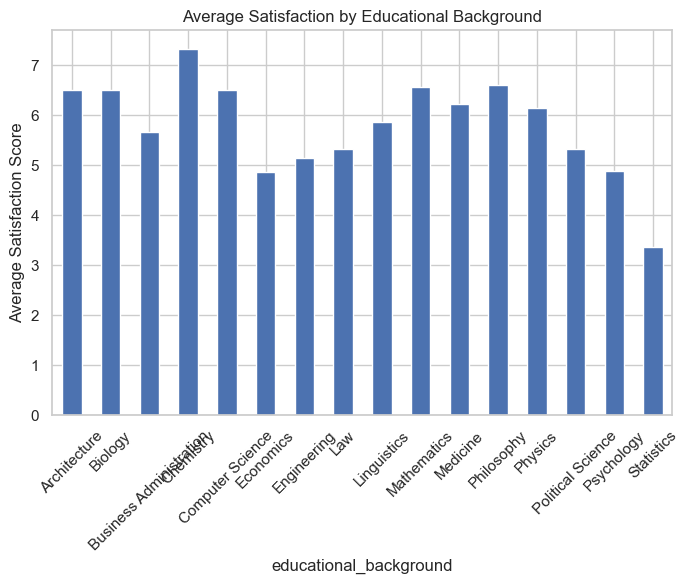

In [18]:
# Step 1: Calculate average satisfaction scores by educational background:
avg_satisfaction_by_education = merged_df.groupby('educational_background')['satisfaction_score'].mean()
display(avg_satisfaction_by_education)

# Step 2: Visualize the average satisfaction scores
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
avg_satisfaction_by_education.plot(kind='bar')
plt.title('Average Satisfaction by Educational Background')
plt.ylabel('Average Satisfaction Score')
plt.xticks(rotation=45)
plt.show()